# Algoritmes voor ontwerp van een nok — ponspers (variant)

Deze variant herbestemt **exact dezelfde nok** als het redraw-/wandstrijk-ontwerp (nok-ontwerp-2) voor een **ponspers** die een gaatje in dunne plaat stanst. De volledige nok blijft ongewijzigd; **alleen het lastprofiel van segment 2 wijzigt**.

### Aangepaste invoer t.o.v. het redraw-/wandstrijk-ontwerp

| parameter | redraw + wandstrijken | ponsen |
|---|---|---|
| heffingswet en timing (45–90–180–305°) | — | **identiek** |
| bewegingswet (cycloïde), $R_0$, $R_r$, excentriciteit $e=8$ mm | — | **identiek** |
| equivalente massa (15 kg), toerental (200 rpm), veer-strategie | — | **identiek** |
| **lastprofiel segment 2** | lineair 250 → 1050 N (verdunning) | **impulsieve schaarpiek + snap-through** |
| gevolg | — | kortere, **scherpere koppelpiek**; piekvermogen $\gg$ gemiddelde (pers-gedrag) |

Het ontwerp mag hier een beetje fictie blijven (bv. het toerental houden we op 200 rpm, terwijl echte ponspersen sneller draaien).

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Toepassing: ponsen (stansen) van een gaatje

Bij ponsen is segment 2 geen geleidelijke verdunning maar een **schaargebeurtenis**: de stempel dringt de plaat binnen, de schaarkracht piekt rond het breukpunt en valt dan **plots weg** zodra het slug doorbreekt (*snap-through*). We plaatsen die piek bewust rond het **midden van segment 2**, waar de volgersnelheid het hoogst is — net als in werkelijkheid, waar de plaat doorgeschaard wordt terwijl de stempel op snelheid is. Dáár zit het herkenbare verschil: de hoge kracht valt nu samen met hoge snelheid, dus een scherpe koppelpiek op de nokas.

- **segment 1 (45°–90°):** de stripper/plaathouder zakt en klemt de plaat → constante ~250 N (ongewijzigd).
- **segment 2 (90°–180°):** de **ponsslag** — kracht loopt op tot ~1050 N rond θ ≈ 135° en valt daarna abrupt weg (snap-through).
- **segment 3 (180°–305°):** terugtrekken; de stripper trekt de stempel uit het gaatje → ~300 N (ongewijzigd).

In [2]:
# specifications (punching press variant):
# Motion is IDENTICAL to the redraw/wall-ironing design; only the segment-2 LOAD changes.

startangle1 = 45;  endangle1 = 90;  theta_seg1 = endangle1-startangle1
startlift1  = 0;   endlift1  = 5;   motionlaw1 = 4   # cycloid

startangle2 = 90;  endangle2 = 180; theta_seg2 = endangle2-startangle2
startlift2  = 5;   endlift2  = 20;  motionlaw2 = 4

startangle3 = 180; endangle3 = 305; theta_seg3 = endangle3-startangle3
startlift3  = 20;  endlift3  = 0;   motionlaw3 = 4

In [3]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

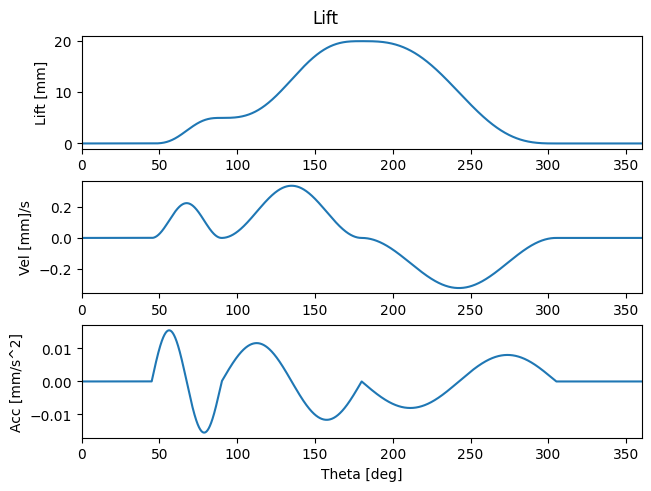

In [4]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

# Add all segments to the motion law (identical to the original design):

lift, vel_deg, acc_deg, vel, acc = addMotionSegment(0,startangle1,0,0,1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(endangle3,360,0,0,1,dtheta)

plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)
plt.show()

In [5]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


In [6]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [7]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [8]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')


### Ontwerp van minimale steekcirkel $R_0$ — identiek aan het origineel

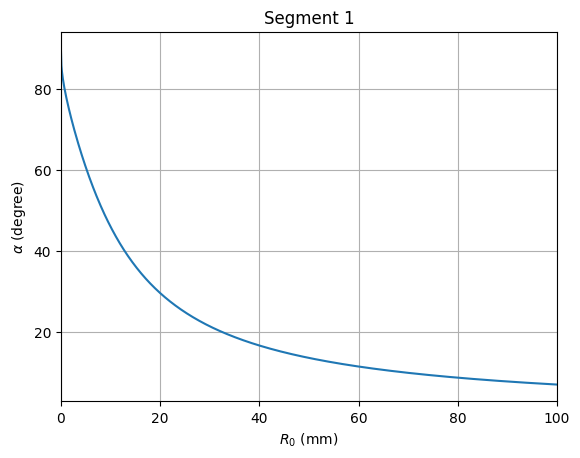

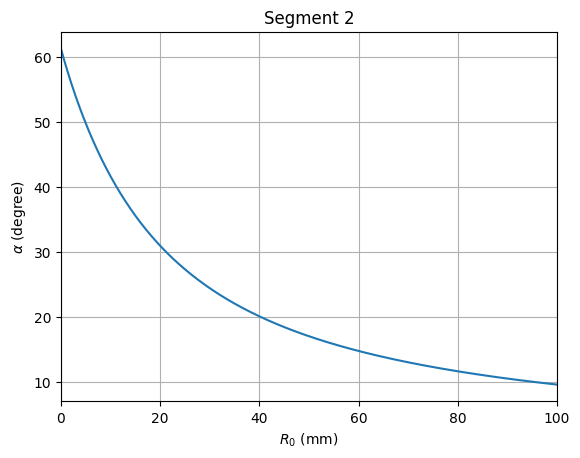

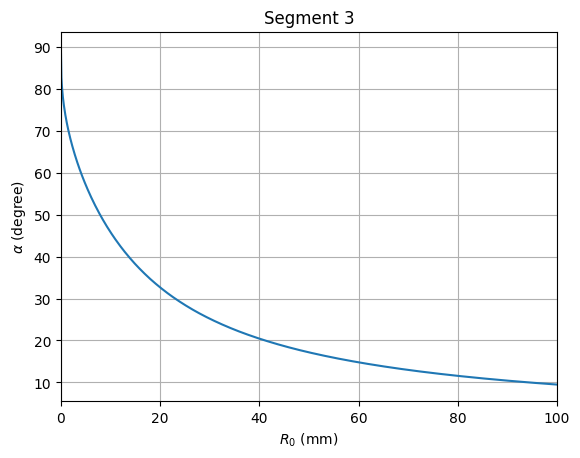

In [9]:
# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)
plt.plot(R0_vec, alpha_max); plt.grid(); plt.title('Segment 1'); plt.xlabel('$R_0$ (mm)'); plt.ylabel(r'$\alpha$ (degree)'); plt.xlim([0,100]); plt.show()
# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)
plt.figure(); plt.plot(R0_vec, alpha_max); plt.grid(); plt.title('Segment 2'); plt.xlabel('$R_0$ (mm)'); plt.ylabel(r'$\alpha$ (degree)'); plt.xlim([0,100]); plt.show()
# segment 3:
Kloomok_Muffley_R0(theta_seg3,startlift3,endlift3,motionlaw3)
plt.figure(); plt.plot(R0_vec, alpha_max); plt.grid(); plt.title('Segment 3'); plt.xlabel('$R_0$ (mm)'); plt.ylabel(r'$\alpha$ (degree)'); plt.xlim([0,100]); plt.show()

We houden $R_0 = 40\text{ mm}$ aan, net als in het origineel.

In [10]:
R0 = 40  # pitch radius in mm

### Ontwerp van straal $R_r$ van de volger — identiek aan het origineel

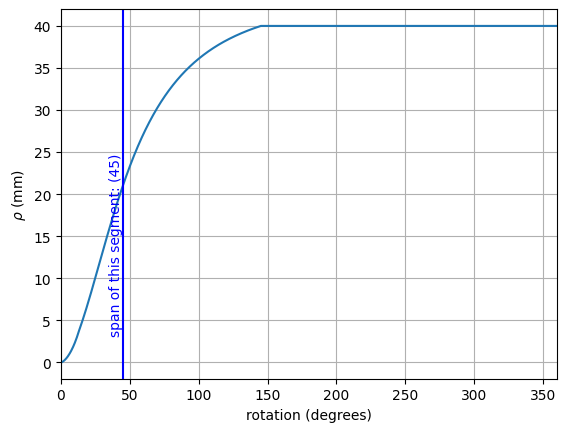

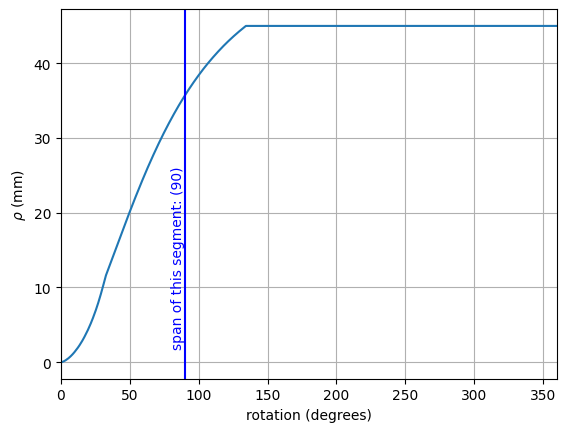

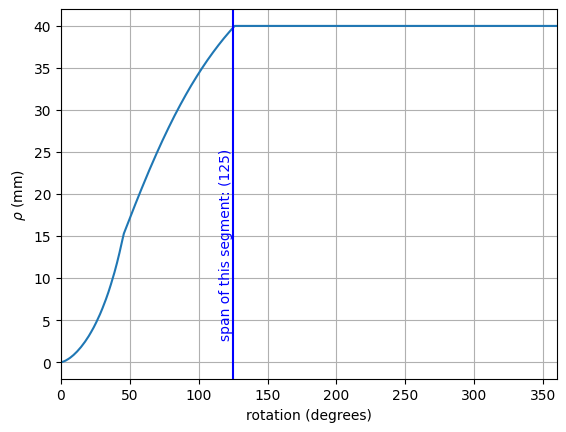

In [11]:
Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg3,startlift3,endlift3,motionlaw3)

We kiezen $R_r = 10$ mm; basiscirkel $R_0 - R_r = 30$ mm — net als in het origineel.

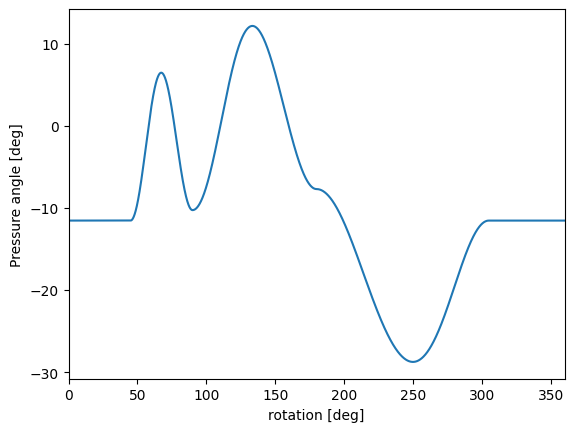

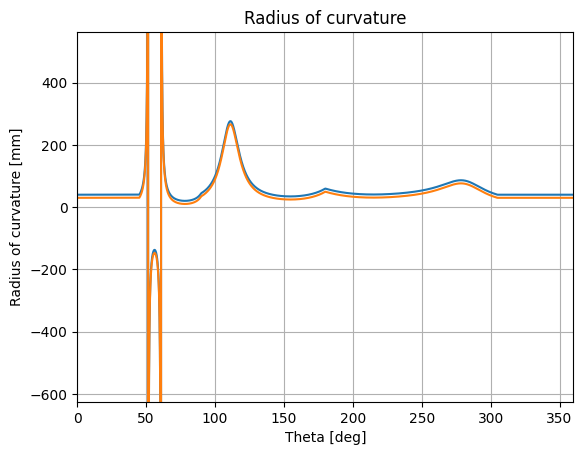

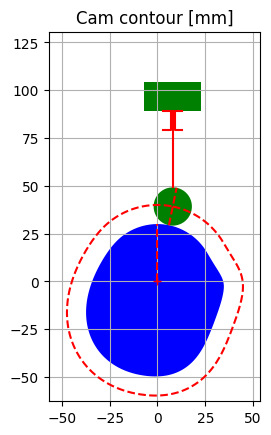

In [12]:
# Kinematics inputs (identical to the original design)
base_radius     = 30
follower_radius = 10
exc = 8.0  # zelfde excentriciteit als gekozen in nok-ontwerp-2

pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)
plotPressureAngle(theta_deg,pressure_angle)

roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

### Lastprofiel — de enige wijziging: een impulsieve ponsslag in segment 2

Segment 1 (stripper-klemkracht) en segment 3 (strippen) blijven gelijk. In segment 2 vervangen we de lineaire verdunningslast door een **schaarpiek met snap-through**, gecentreerd rond θ ≈ 135° (de plaats van maximale volgersnelheid).

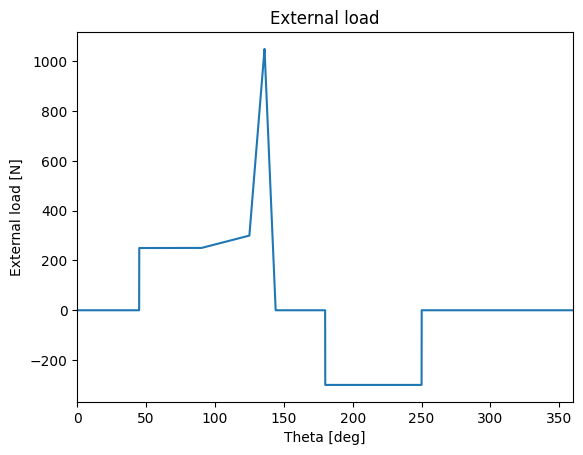

In [13]:
# external load -- punching

ext_load = addLoadSegment(45,  90,  250,  250, dtheta)   # stripper/plaathouder klemt (ongewijzigd)
ext_load = addLoadSegment(90,  125, 250,  300, dtheta)   # nadering, lage kracht
ext_load = addLoadSegment(125, 136, 300, 1050, dtheta)   # schaarkracht stijgt naar piek (op snelheid)
ext_load = addLoadSegment(136, 144, 1050,   0, dtheta)   # snap-through: slug breekt, kracht valt weg
ext_load = addLoadSegment(144, 180, 0,      0, dtheta)   # overtravel naar onderpunt, geen last
ext_load = addLoadSegment(180, 250, -300, -300, dtheta)  # strippen op de terugkeer (ongewijzigd)

plotExternalLoad(theta_deg,ext_load)

### Veer-dimensionering — zelfde strategie (N ≥ 0)

Preload F_v0          : 150 N
Chosen spring rate    : 22.41 N/mm (margin 20%)
Minimum contact force : 62.9 N  (> 0  =>  force closure OK)
Maximum contact force : 1502.9 N


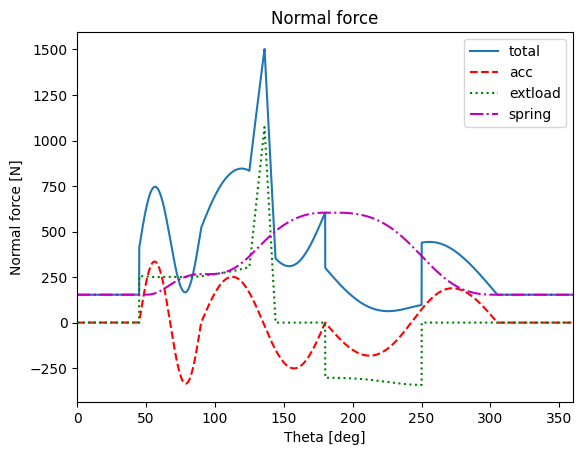

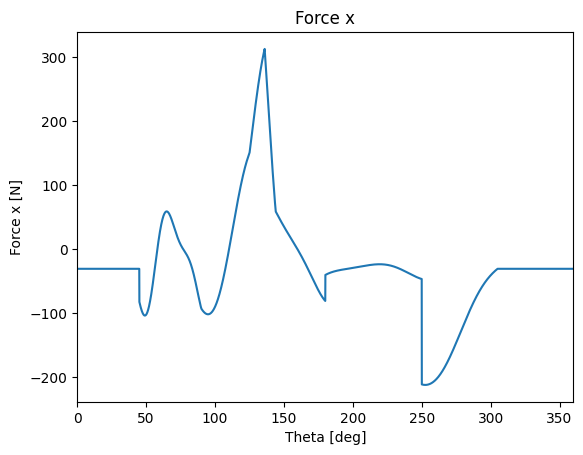

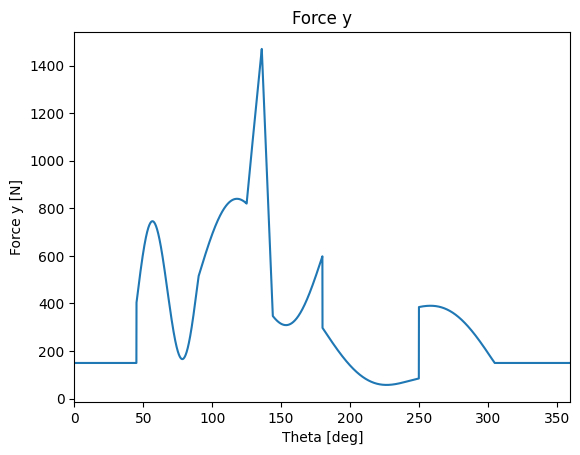

In [14]:
# Spring design (Les 6): choose preload, compute spring rate so that N >= 0

mass  = 15
rpm   = 200
omega = rpm * 2*np.pi / 60

F_inert = mass * acc/1000 * omega**2
spring_preload = 150.0
mask  = lift > 1e-6
k_min = max(0.0, np.max(-(spring_preload + ext_load + F_inert)[mask] / lift[mask]))
safety = 1.2
spring_constant = k_min * safety
print('Preload F_v0          : %.0f N' % spring_preload)
print('Chosen spring rate    : %.2f N/mm (margin %.0f%%)' % (spring_constant, (safety-1)*100))

[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(
    rpm, lift, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc)
print('Minimum contact force : %.1f N  (> 0  =>  force closure OK)' % np.min(normalforce_tot))
print('Maximum contact force : %.1f N' % np.max(normalforce_tot))
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

### Dynamische analyse: koppel, motorvermogen en vliegwiel

Het koppel op de nokas is $M(\theta) = N\cos(\alpha)\,\dfrac{dS}{d\theta}$ (axiale kracht × volgersnelheid). Doordat de ponspiek nu rond θ ≈ 135° valt — waar de snelheid hoog is — ontstaat een korte, scherpe koppelpiek. Het **piekkoppel** ligt hoger dan bij de gladde duntrek-last, en vooral: het **piekvermogen** ligt ver boven het gemiddelde. Dat is net waarom een pers een vliegwiel met een **kleine motor** combineert: de motor levert het gemiddelde, het vliegwiel buffert de korte, hoge ponspiek. (De benodigde vliegwieltraagheid zelf valt vergelijkbaar — zelfs iets kleiner — uit dan bij het origineel, omdat de ponsenergie per slag kort en beperkt is; het kenmerkende is de scherpe vermogenspiek, niet een grotere traagheid.)

Mean torque  M_av     = 1.59 Nm
Peak torque  |M|max   = 28.04 Nm
Mean power   P_motor  = 33.2 W
Peak power   ~       = 587 W
Peak/mean power ratio = 18 x  (pers-signatuur)


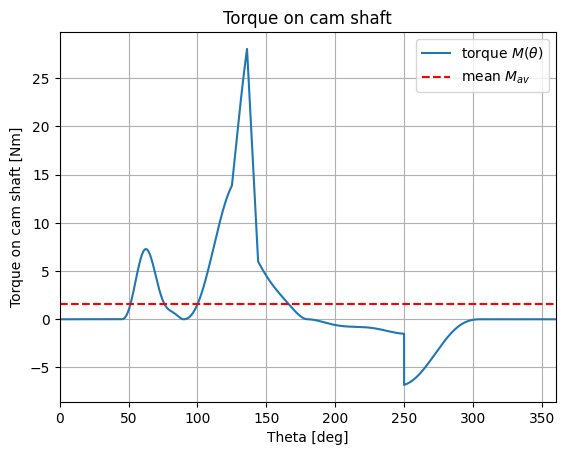

In [15]:
# Torque on the cam shaft and mean power
M_load = normalforce_tot * np.cos(pressure_angle) * (vel / 1000.0)   # [Nm]
M_av    = np.mean(M_load)
P_motor = M_av * omega
print('Mean torque  M_av     = %.2f Nm' % M_av)
print('Peak torque  |M|max   = %.2f Nm' % np.max(np.abs(M_load)))
print('Mean power   P_motor  = %.1f W'  % P_motor)
P_peak = np.max(np.abs(M_load))*omega
print('Peak power   ~       = %.0f W' % P_peak)
print('Peak/mean power ratio = %.0f x  (pers-signatuur)' % (P_peak/abs(P_motor)))

plt.figure()
plt.plot(theta_deg, M_load, label=r'torque $M(\theta)$')
plt.axhline(M_av, color='r', ls='--', label=r'mean $M_{av}$')
plt.xlabel('Theta [deg]'); plt.ylabel('Torque on cam shaft [Nm]'); plt.xlim([0,360]); plt.grid(); plt.legend(); plt.title('Torque on cam shaft'); plt.show()

Maximum work surplus  A_max = 10.36 J
Required inertia      I     = 0.4725 kg*m^2  (K = 5%)
Steel disc: d = 400 mm  ->  thickness t = 23.9 mm,  mass = 23.6 kg


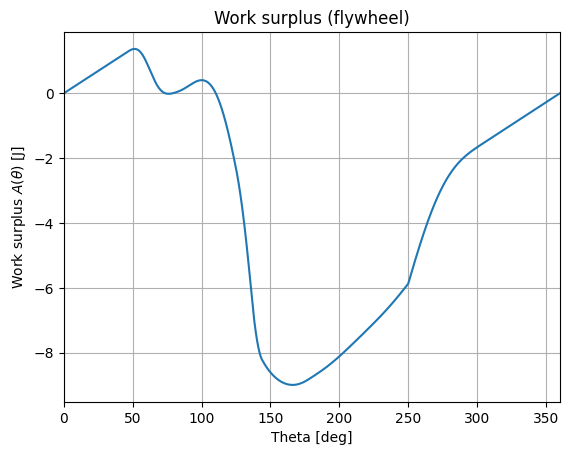

In [16]:
# Flywheel design (Les 4)
dtheta_rad = dtheta * np.pi / 180
A_theta    = np.cumsum(M_av - M_load) * dtheta_rad
A_max      = np.max(A_theta) - np.min(A_theta)
K          = 0.05
I_flywheel = A_max / (K * omega**2)
print('Maximum work surplus  A_max = %.2f J' % A_max)
print('Required inertia      I     = %.4f kg*m^2  (K = %.0f%%)' % (I_flywheel, K*100))
rho = 7850; d = 0.40
t   = 32 * I_flywheel / (np.pi * rho * d**4)
m_fly = rho * np.pi * (d/2)**2 * t
print('Steel disc: d = %.0f mm  ->  thickness t = %.1f mm,  mass = %.1f kg' % (d*1000, t*1000, m_fly))

plt.figure()
plt.plot(theta_deg, A_theta)
plt.xlabel('Theta [deg]'); plt.ylabel(r'Work surplus $A(\theta)$ [J]'); plt.xlim([0,360]); plt.grid(); plt.title('Work surplus (flywheel)'); plt.show()

### Kostenraming: motor en energieverbruik

Opgezochte richtprijzen (België, 2026): de **industriële elektriciteitsprijs** ligt rond **0,12–0,18 €/kWh** (we rekenen met 0,15 €/kWh), en een kleine **3-fasige motor van 0,18 kW** (IE2) kost ongeveer **90 €** (≈ £77 excl. btw).

Het cruciale punt: dankzij het **vliegwiel** hoeft de motor enkel het **gemiddelde** asvermogen te leveren (tientallen W), niet het **piekvermogen** (honderden W). Daardoor volstaat de kleinste standaardmotor en blijven zowel de motor- als de energiekost klein. Zonder vliegwiel zou je de motor op het piekvermogen moeten dimensioneren — een veel grotere en duurdere motor.

In [17]:
# Kostenraming: motor en energieverbruik
# Opgezochte richtprijzen (Belgie, 2026):
#   - industriele elektriciteitsprijs ~0.12-0.18 EUR/kWh  -> we nemen 0.15
#   - kleine 3-fasige motor 0.18 kW (IE2): ~90 EUR (= 77 GBP excl. btw)
price_kwh  = 0.15      # EUR/kWh (industrieel, BE 2026)
hours_year = 4000      # bedrijfsuren per jaar (2 ploegen, aanname)
eff_motor  = 0.70      # rendement kleine motor bij deellast (aanname)
motor_cost = 90.0      # EUR, kleine 0.18 kW 3-fasige motor

P_mean = abs(M_av) * omega                 # gemiddeld asvermogen [W] (vliegwiel vangt pieken op)
P_peak = np.max(np.abs(M_load)) * omega    # piekasvermogen [W]

P_in        = P_mean / eff_motor           # opgenomen elektrisch vermogen [W]
energy_year = P_in/1000 * hours_year       # kWh/jaar
cost_year   = energy_year * price_kwh      # EUR/jaar

print('Gemiddeld asvermogen    : %5.0f W  -> 0.18 kW motor volstaat ruim  (~%.0f EUR)' % (P_mean, motor_cost))
print('Piekasvermogen          : %5.0f W  (zonder vliegwiel hierop te dimensioneren)' % P_peak)
print('Opgenomen vermogen      : %5.0f W' % P_in)
print('Energieverbruik         : %5.0f kWh/jaar   (bij %d h/jaar)' % (energy_year, hours_year))
print('Energiekost             : %5.0f EUR/jaar   (bij %.2f EUR/kWh)' % (cost_year, price_kwh))
print('Motorkost (eenmalig)    : %5.0f EUR' % motor_cost)

Gemiddeld asvermogen    :    33 W  -> 0.18 kW motor volstaat ruim  (~90 EUR)
Piekasvermogen          :   587 W  (zonder vliegwiel hierop te dimensioneren)
Opgenomen vermogen      :    47 W
Energieverbruik         :   190 kWh/jaar   (bij 4000 h/jaar)
Energiekost             :    28 EUR/jaar   (bij 0.15 EUR/kWh)
Motorkost (eenmalig)    :    90 EUR


### Besluit

De nok zelf — heffingswet, profiel, contour, drukhoek, excentriciteit, veer — is **identiek** aan het redraw-/wandstrijk-ontwerp; alleen het lastprofiel van segment 2 is vervangen door een impulsieve ponsslag. Het verschil zit volledig in de **dynamica**: omdat de hoge kracht nu samenvalt met hoge snelheid, wordt het koppel een korte, scherpe piek. Het piekkoppel is hoger en vooral het **piekvermogen is een veelvoud van het gemiddelde** (≈ 18× tegenover ≈ 9× bij het origineel). Dat is de typische **pers-signatuur**: een klein motorvermogen volstaat omdat het vliegwiel de korte, hoge ponspiek opvangt. (De vliegwieltraagheid zelf komt vergelijkbaar uit — iets kleiner zelfs — omdat de ponsenergie per slag beperkt is.) Zo blijft het herkenbaar dezelfde nok, maar met een realistisch ander procédé en een eigen dynamisch verhaal.